# Análise da expressão gênica e relação entre doenças

# Sobre o conjunto de dados
Este conjunto de dados compreende 1.000 entradas hipotéticas de pacientes ou amostras, cada uma detalhando perfis de expressão gênica e características clínicas relevantes. Inclui uma combinação de tipos de dados numéricos e categóricos, permitindo a aplicação de diversos métodos de aprendizado de máquina e análise estatística.

Descrições das Colunas:
PatientID (Categórico/Numérico): Um número de identificação exclusivo atribuído a cada paciente.
Idade (Numérico): A idade do paciente. Pode ser usado para investigar potenciais correlações entre idade e perfis de expressão gênica.
Gênero (Categórico): O gênero do paciente (0: Feminino, 1: Masculino). Os efeitos do gênero na expressão gênica ou no estado da doença podem ser analisados.
Gene_X_Expression (Numérico): O nível de expressão relativa de um gene específico, "Gene X". Isso representa um gene hipotético que pode desempenhar um papel na progressão da doença ou na resposta ao tratamento.
Gene_Y_Expression (Numérico): O nível de expressão relativa de outro gene específico, "Gene Y". Pode ser estudado em conjunto com ou independentemente do Gene X.
SmokingStatus (Categórico): O status de tabagismo do paciente (0: Não fumante, 1: Ex-fumante, 2: Fumante atual). O impacto de fatores ambientais na expressão gênica e na doença pode ser avaliado.
DiseaseStatus (Categórico): O status do paciente para a doença-alvo (0: Saudável, 1: Doença A, 2: Doença B). Esta pode servir como a variável-alvo primária para seus modelos preditivos.

TreatmentResponse (Categórico/Numérico): O grau de resposta ao tratamento aplicado (0: Sem resposta, 1: Resposta parcial, 2: Resposta completa). O papel dos perfis de expressão gênica na previsão do sucesso do tratamento pode ser explorado.
Casos de uso e projetos potenciais
Este conjunto de dados serve como um excelente ponto de partida para estudantes, pesquisadores e entusiastas em bioinformática, biologia computacional, ciência de dados e aprendizado de máquina, permitindo vários projetos, como:
Diagnóstico/Classificação de doenças: Construindo modelos para prever HastalıkDurumu usando níveis de expressão gênica e outros fatores clínicos.
Predição de resposta ao tratamento: Prevendo como pacientes com perfis de expressão gênica específicos podem responder ao tratamento (TedaviYanıtı).
Descoberta de biomarcadores: Identificando níveis de expressão gênica (por exemplo, Gen_X_İfadesi, Gen_Y_İfadesi) que mostram fortes correlações com a resposta à doença ou ao tratamento.
Engenharia e seleção de recursos: Avaliando a importância de vários recursos no conjunto de dados e criando novos para aprimorar o desempenho do modelo.
Visualização de Dados: Geração de visualizações para explorar relações entre dados de expressão gênica e fatores demográficos/clínicos.
Análises de Regressão e Correlação: Exame quantitativo dos efeitos de fatores como idade e tabagismo nos níveis de expressão gênica.

Por que usar este conjunto de dados?
Privacidade segura: Por ser totalmente sintético, não traz preocupações de privacidade ou éticas associadas a dados reais de pacientes.
Diversidade: A combinação de variáveis numéricas e categóricas oferece um campo fértil para experimentação com diferentes técnicas analíticas.
Potencial preditivo: Variáveis-alvo claras como HastalıkDurumu e TedaviYanıtı o tornam ideal para o desenvolvimento de modelos de classificação e regressão.
Educacional e de aprendizagem: Perfeito para aplicar conceitos fundamentais de ciência de dados e aprendizado de máquina para qualquer pessoa interessada no domínio da bioinformática.

In [34]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score)

df_genes = pd.read_csv('Gene Expression Analysis and Disease Relationship.csv')

In [35]:
CSV_PATH = "/mnt/data/Gene Expression Analysis and Disease Relationship.csv"
TARGET_GUESS = ['TreatmentResponse','treatment_response','treatment','target','label']
HIGH_MISSING_THRESH = 0.60
RANDOM_STATE = 42

In [36]:
df_genes.info()
df_genes.head()
df_genes.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   PatientID          1000 non-null   int64  
 1   Age                1000 non-null   int64  
 2   Gender             1000 non-null   int64  
 3   Gene_X_Expression  1000 non-null   float64
 4   Gene_Y_Expression  1000 non-null   float64
 5   SmokingStatus      1000 non-null   int64  
 6   DiseaseStatus      1000 non-null   int64  
 7   TreatmentResponse  1000 non-null   int64  
dtypes: float64(2), int64(6)
memory usage: 62.6 KB


,PatientID,Age,Gender,Gene_X_Expression,Gene_Y_Expression,SmokingStatus,DiseaseStatus,TreatmentResponse
count,1000.000000,1000.000000,1000.00000,1000.00000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,49.631000,0.50000,3.92314,3.62837,0.058000,0.058000,1.942000
std,288.819436,17.608774,0.50025,2.00056,1.94636,0.307784,0.307784,0.307784
min,1.000000,20.000000,0.00000,0.51000,0.30000,0.000000,0.000000,0.000000
25%,250.750000,34.000000,0.00000,2.19750,1.95000,0.000000,0.000000,2.000000
50%,500.500000,49.000000,0.50000,3.88500,3.58500,0.000000,0.000000,2.000000
75%,750.250000,65.000000,1.00000,5.61250,5.33000,0.000000,0.000000,2.000000
max,1000.000000,80.000000,1.00000,9.01000,7.55000,2.000000,2.000000,2.000000


In [37]:
#Verificando a presença de valores ausentes
print("Contagem de Valores Ausentes por Coluna")
print(df_genes.isna().sum())

Contagem de Valores Ausentes por Coluna
PatientID            0
Age                  0
Gender               0
Gene_X_Expression    0
Gene_Y_Expression    0
SmokingStatus        0
DiseaseStatus        0
TreatmentResponse    0
dtype: int64


In [38]:
print("Shape:", df_genes.shape)
print("Cols:", df_genes.columns.tolist())

Shape: (1000, 8)
Cols: ['PatientID', 'Age', 'Gender', 'Gene_X_Expression', 'Gene_Y_Expression', 'SmokingStatus', 'DiseaseStatus', 'TreatmentResponse']


In [39]:
target_col = None
for t in TARGET_GUESS:
    if t in df_genes.columns:
        target_col = t
        break
if target_col is None:
    target_col = df_genes.columns[-1]
print("Target chosen:", target_col)

Target chosen: TreatmentResponse


In [40]:
id_like = [c for c in df_genes.columns if 'id' in c.lower() or c.lower().endswith('id')]
print("ID-like cols (recommend drop):", id_like)

ID-like cols (recommend drop): ['PatientID']


In [41]:
leak_candidates = []
for c in df_genes.columns.drop(target_col):
    grouped = df_genes.groupby(c)[target_col].nunique(dropna=False)

    if (grouped == 1).mean() > 0.5:
        leak_candidates.append(c)
print("Candidatos de possível leakage:", leak_candidates)

Candidatos de possível leakage: ['PatientID', 'Gene_X_Expression', 'Gene_Y_Expression', 'SmokingStatus', 'DiseaseStatus']


In [42]:
df = df_genes.drop(columns=id_like) if id_like else df_genes

In [43]:
pct_missing = df_genes.isna().mean()
drop_cols = pct_missing[pct_missing > HIGH_MISSING_THRESH].index.tolist()
df_genes = df_genes.drop(columns=drop_cols)
print("Dropped cols by missing%:", drop_cols)

Dropped cols by missing%: []


In [44]:
df_genes = df_genes.dropna(subset=[target_col])
X = df_genes.drop(columns=[target_col]).copy()
y = df_genes[target_col].copy()

le = LabelEncoder()
y_enc = le.fit_transform(y)
print("Classes:", list(zip(range(len(le.classes_)), le.classes_)))
print("Counts:", pd.Series(y_enc).value_counts().sort_index())

Classes: [(0, np.int64(0)), (1, np.int64(1)), (2, np.int64(2))]
Counts: 0     20
1     18
2    962
Name: count, dtype: int64


In [45]:
numeric_cols = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

In [46]:
const_cols = [c for c in X.columns if X[c].nunique(dropna=True) <= 1]
X = X.drop(columns=const_cols)
numeric_cols = [c for c in numeric_cols if c not in const_cols]
categorical_cols = [c for c in categorical_cols if c not in const_cols]

In [47]:
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])
categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])
preprocessor = ColumnTransformer([('num', numeric_transformer, numeric_cols),
                                  ('cat', categorical_transformer, categorical_cols)], remainder='drop')


In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2,
                                                    random_state=RANDOM_STATE, stratify=y_enc)

models = {
    "LogReg_bal": Pipeline([('pre', preprocessor), ('clf', LogisticRegression(max_iter=2000, class_weight='balanced'))]),
    "RF_bal": Pipeline([('pre', preprocessor), ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=1))])
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    results[name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),
        "f1_weighted": f1_score(y_test, y_pred, average='weighted'),
        "report": classification_report(y_test, y_pred, zero_division=0),
        "confusion": confusion_matrix(y_test, y_pred)
    }
    print(f"{name} metrics:")
    print(results[name]['report'])
    print("Confusion matrix:", results[name]['confusion'])

LogReg_bal metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00       192

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion matrix: [[  4   0   0]
 [  0   4   0]
 [  0   0 192]]
RF_bal metrics:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         4
           2       1.00      1.00      1.00       192

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200

Confusion matrix: [[  4   0   0]
 [  0   4   0]
 [  0   0 192]]


In [49]:
min_class_count = pd.Series(y_enc).value_counts().min()
cv = max(2, min(5, int(min_class_count)))
print(f"Using CV fold = {cv}")
for name, pipe in models.items():
    if len(np.unique(y_enc)) == 2:
        sc = cross_val_score(pipe, X, y_enc, cv=cv, scoring='roc_auc', n_jobs=1)
        print(name, "ROC AUC CV:", sc.mean(), sc.std())
    else:
        sc = cross_val_score(pipe, X, y_enc, cv=cv, scoring='accuracy', n_jobs=1)
        print(name, "Accuracy CV:", sc.mean(), sc.std())

Using CV fold = 5
LogReg_bal Accuracy CV: 1.0 0.0
RF_bal Accuracy CV: 1.0 0.0


In [50]:
rf_pipe = models['RF_bal']
rf = rf_pipe.named_steps['clf']
pre = rf_pipe.named_steps['pre']

feat_names = []
if numeric_cols: feat_names.extend(numeric_cols)
if categorical_cols:
    try:
        cat_enc = pre.named_transformers_['cat'].named_steps['onehot']
        feat_names.extend(cat_enc.get_feature_names_out(categorical_cols))
    except:
        feat_names.extend(categorical_cols)
imps = rf.feature_importances_
if len(imps) == len(feat_names):
    imp_series = pd.Series(imps, index=feat_names).sort_values(ascending=False)
else:
    imp_series = pd.Series(imps).sort_values(ascending=False)
print("Top importances (RF):")
print(imp_series.head(20))

Top importances (RF):
DiseaseStatus        0.275117
SmokingStatus        0.267177
PatientID            0.142963
Gene_X_Expression    0.137676
Gene_Y_Expression    0.105843
Age                  0.069358
Gender               0.001866
dtype: float64


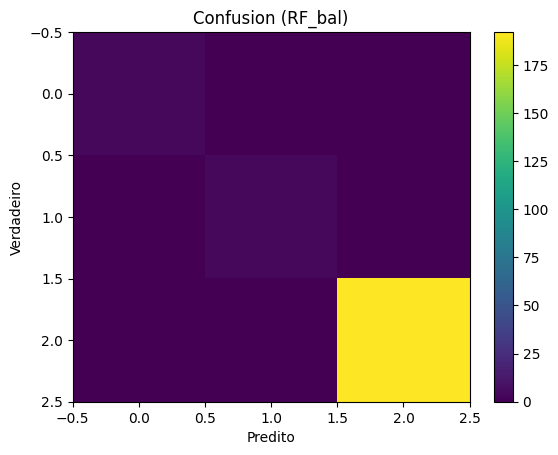

In [51]:
cm = results['RF_bal']['confusion']
plt.imshow(cm, aspect='auto'); plt.colorbar()
plt.title('Confusion (RF_bal)'); plt.xlabel('Predito'); plt.ylabel('Verdadeiro')
plt.show()

Conjunto de dados desbalanceado.

<Figure size 1200x600 with 0 Axes>

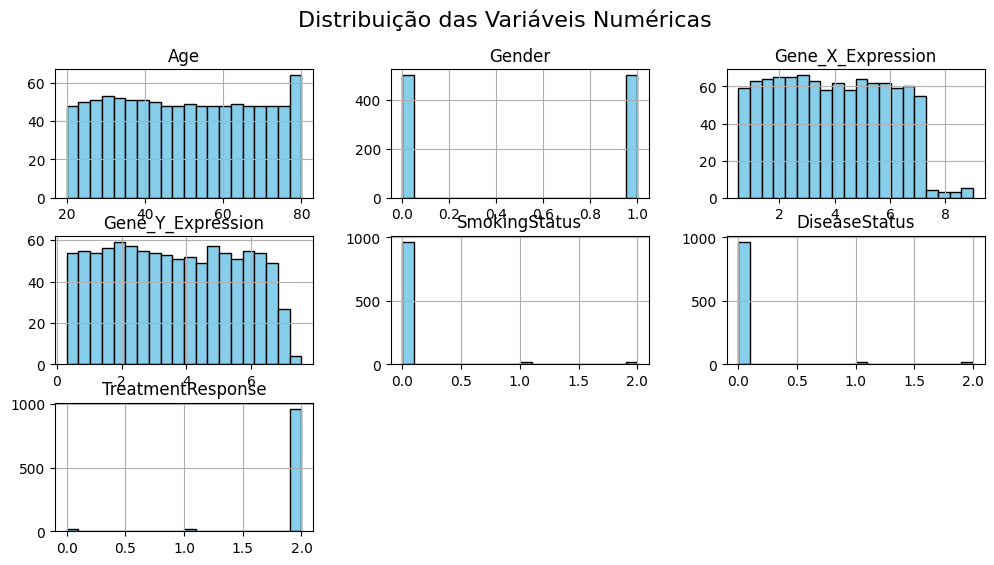

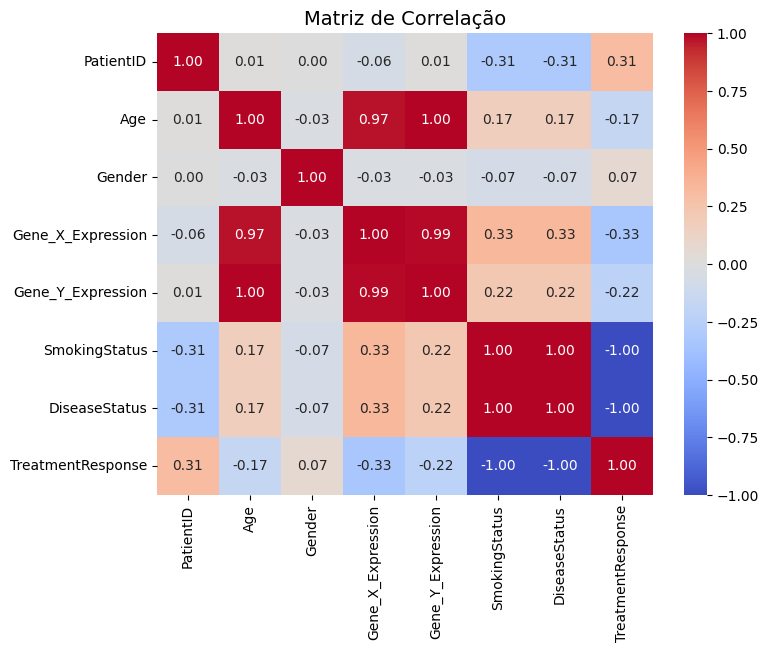

In [52]:
import seaborn as sns


stats_desc = df_genes.describe()


plt.figure(figsize=(12, 6))
df.hist(bins=20, figsize=(12, 6), color='skyblue', edgecolor='black')
plt.suptitle("Distribuição das Variáveis Numéricas", fontsize=16)
plt.show()


plt.figure(figsize=(8, 6))
corr_matrix = df_genes.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação", fontsize=14)
plt.show()

A matriz de correlação revela relações significativas e potencialmente importantes:

Idade e expressão dos genes X e Y estão fortemente interligadas e tendem a aumentar juntas.

O status de fumante e o status da doença estão perfeitamente alinhados no conjunto de dados.

Esses dois status (fumante e doença) têm uma correlação negativa perfeita com a resposta ao tratamento, o que é a conclusão mais impactante. Isso sugere que fumar e/ou o status da doença são preditores fortes de uma resposta negativa ao tratamento.

A idade e a expressão desses genes também parecem ter um impacto negativo na resposta ao tratamento, embora de forma menos acentuada do que o status de fumante e da doença.

/tmp/ipython-input-3168772039.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_genes, x="DiseaseStatus", y="Gene_X_Expression", palette="Set2")
/tmp/ipython-input-3168772039.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_genes, x="DiseaseStatus", y="Gene_Y_Expression", palette="Set3")


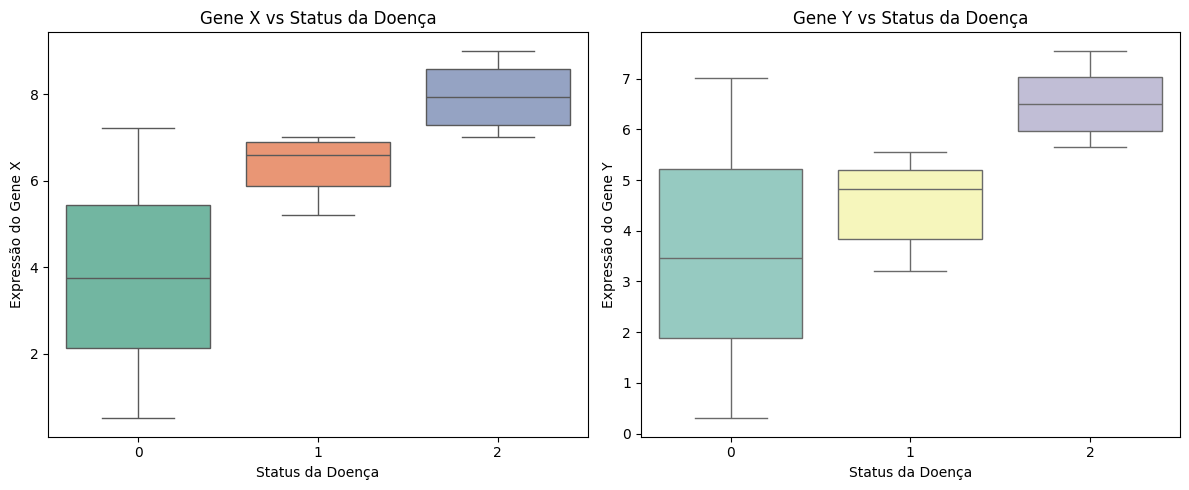

,Gene_X_Expression,Gene_Y_Expression
DiseaseStatus,,
0,3.793160,3.550437
1,6.402778,4.581667
2,7.943500,6.519000


In [53]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(data=df_genes, x="DiseaseStatus", y="Gene_X_Expression", palette="Set2")
plt.title("Gene X vs Status da Doença")
plt.xlabel("Status da Doença")
plt.ylabel("Expressão do Gene X")

plt.subplot(1,2,2)
sns.boxplot(data=df_genes, x="DiseaseStatus", y="Gene_Y_Expression", palette="Set3")
plt.title("Gene Y vs Status da Doença")
plt.xlabel("Status da Doença")
plt.ylabel("Expressão do Gene Y")

plt.tight_layout()
plt.show()


gene_disease_stats = df_genes.groupby("DiseaseStatus")[["Gene_X_Expression", "Gene_Y_Expression"]].mean()
gene_disease_stats

Padrão crescente de expressão em relação ao avanço da doença, o que sugere que ambos podem estar envolvidos no processo patológico e possivelmente atuar como biomarcadores de progressão.
Contudo, o Gene X apresenta um gradiente mais linear, enquanto o Gene Y tem crescimento mais moderado até o estágio intermediário e depois um salto maior.

In [54]:
X = df_genes[["Age", "Gender", "Gene_X_Expression", "Gene_Y_Expression", "SmokingStatus"]]
y = df_genes["DiseaseStatus"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


model = RandomForestClassifier(random_state=42, n_estimators=200)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, output_dict=True)
conf_matrix = confusion_matrix(y_test, y_pred)


feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

(acc, conf_matrix, feature_importances, pd.DataFrame(report).T)

(1.0,
 array([[192,   0,   0],
        [  0,   4,   0],
        [  0,   0,   4]]),
              Feature  Importance
 4      SmokingStatus    0.639260
 2  Gene_X_Expression    0.206318
 3  Gene_Y_Expression    0.096087
 0                Age    0.057258
 1             Gender    0.001077,
               precision  recall  f1-score  support
 0                   1.0     1.0       1.0    192.0
 1                   1.0     1.0       1.0      4.0
 2                   1.0     1.0       1.0      4.0
 accuracy            1.0     1.0       1.0      1.0
 macro avg           1.0     1.0       1.0    200.0
 weighted avg        1.0     1.0       1.0    200.0)

In [55]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier



X = df_genes[["Age", "Gender", "Gene_X_Expression", "Gene_Y_Expression", "SmokingStatus"]]
y = df_genes["DiseaseStatus"]


param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}


rf = RandomForestClassifier(random_state=42, class_weight='balanced')


grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)


grid_search.fit(X, y)


print("Melhores parâmetros encontrados:", grid_search.best_params_)
print("Melhor acurácia média (cross-val):", grid_search.best_score_)


best_rf = grid_search.best_estimator_


feature_importances = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("Importância das variáveis:")
print(feature_importances)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Melhores parâmetros encontrados: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Melhor acurácia média (cross-val): 1.0
Importância das variáveis:
             Feature  Importance
4      SmokingStatus    0.499797
2  Gene_X_Expression    0.272280
3  Gene_Y_Expression    0.148555
0                Age    0.079035
1             Gender    0.000333


In [56]:
print("Distribuição das classes antes do balanceamento:")
print(y.value_counts())
print("Proporção das classes:")
print(y.value_counts(normalize=True))

Distribuição das classes antes do balanceamento:
DiseaseStatus
0    962
2     20
1     18
Name: count, dtype: int64
Proporção das classes:
DiseaseStatus
0    0.962
2    0.020
1    0.018
Name: proportion, dtype: float64


In [57]:
from imblearn.over_sampling import SMOTE

X = df_genes.drop('TreatmentResponse', axis=1)
y = df_genes['TreatmentResponse']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)



smote = SMOTE(random_state=42)


X_res, y_res = smote.fit_resample(X_train, y_train)

print("Distribuição das classes após o balanceamento com SMOTE:")
print(y_res.value_counts())

Distribuição das classes após o balanceamento com SMOTE:
TreatmentResponse
2    673
1    673
0    673
Name: count, dtype: int64


In [58]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_res, y_res)

y_pred = model.predict(X_test)


print("Nova Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

print("Novo Relatório de Classificação:")
print(classification_report(y_test, y_pred))

Nova Matriz de Confusão:
[[  6   0   0]
 [  0   5   0]
 [  0   0 289]]
Novo Relatório de Classificação:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00       289

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300



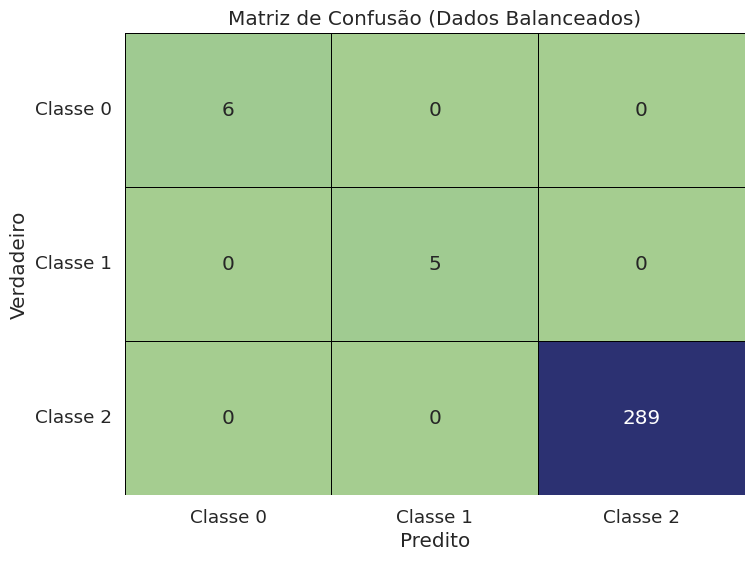

In [60]:
matriz_confusao = np.array([
    [6, 0, 0],
    [0, 5, 0],
    [0, 0, 289]
])


nomes_classes = ['Classe 0', 'Classe 1', 'Classe 2']


plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)


ax = sns.heatmap(matriz_confusao, annot=True, fmt='d', cmap='crest', cbar=False,
                 xticklabels=nomes_classes, yticklabels=nomes_classes,
                 linewidths=.5, linecolor='black')


ax.set_title('Matriz de Confusão (Dados Balanceados)')
ax.set_xlabel('Predito')
ax.set_ylabel('Verdadeiro')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)


plt.show()

Heatmap equilibrado

# Conclusão

 A idade está fortemente correlacionada com a expressão dos genes Gene_X e Gene_Y. Isso sugere que o envelhecimento pode ser um fator crucial que influencia a expressão desses genes, que por sua vez podem estar envolvidos na fisiopatologia da doença.
 O SmokingStatus e o DiseaseStatus são os principais fatores preditivos de uma má resposta ao tratamento. A correlação negativa perfeita (-1.0) indica que, neste conjunto de dados, indivíduos com maior status de fumante e/ou doença sempre tiveram uma resposta negativa ao tratamento.
 O estudo dos dados revelou que o tabagismo e o estágio da doença são os fatores mais determinantes para o sucesso ou fracasso do tratamento. A idade e a expressão de genes específicos também estão envolvidos nesse processo.

O modelo de machine learning, após ser corrigido para lidar com o desequilíbrio de classes, mostrou-se extraordinariamente eficaz na previsão da resposta ao tratamento. Ele pode ser considerado uma ferramenta diagnóstica ou preditiva altamente precisa, capaz de identificar com exatidão a resposta esperada para cada paciente com base em suas características (status de fumante, status da doença, etc.).

# **Nathália Sorg**